In [298]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import random
#random.seed(1)

In [299]:
def read_file(file_name):
    path = Path(file_name)
    if not path.exists():
        print("File not found")
        return None

    text = path.read_text(encoding="utf-8", errors="ignore")
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    return lines

In [300]:
lines = read_file("p_median_capacitated.txt")    
print(lines[:5])
print("Total lines:", len(lines))

['1 713', '50 5 120', '1 2 62 3', '2 80 25 14', '3 36 88 1']
Total lines: 1336


In [301]:
def parse_instances(lines):
    i = 0
    instances = []

    while i < len(lines):
        inst_id, best = map(int, lines[i].split())
        i += 1

        n, p, cap = map(int, lines[i].split())
        i += 1

        xs, ys, ds = [], [], []
        for _ in range(n):
            parts = lines[i].split()
            i += 1
            xs.append(float(parts[1]))
            ys.append(float(parts[2]))
            ds.append(float(parts[3]))

        inst = {
            "id": inst_id,
            "best": best,
            "n": n,
            "p": p,
            "cap": cap,
            "x": np.array(xs),
            "y": np.array(ys),
            "demand": np.array(ds),
        }

        instances.append(inst)

    return instances

In [302]:
# ---------- Preprocessing ----------
def build_distance_matrix(inst):
    x = inst["x"]
    y = inst["y"]

    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]

    dist = np.sqrt(dx*dx + dy*dy)

    inst["dist"] = dist
    return inst


In [303]:
# ---------- Representation ----------
def create_random_chromosome(inst):
    n = inst["n"]
    p = inst["p"]

    chromosome = random.sample(range(n), p)
    return chromosome

In [304]:
# ---------- Objectives ----------
def compute_dispersion(inst, chromosome):
    dist = inst["dist"]

    min_d = float("inf")

    for i in range(len(chromosome)):
        for j in range(i+1, len(chromosome)):
            f1 = chromosome[i]
            f2 = chromosome[j]

            d = dist[f1][f2]

            if d < min_d:
                min_d = d

    return min_d

In [305]:
def assign_customers_greedy(inst, chromosome):
    """
    Greedy capacity assignment:
      - customers sorted by demand descending
      - each customer goes to nearest median with remaining capacity
    Returns: feasible(bool), total_cost(float), unassigned_count(int)
    """
    dist = inst["dist"]
    demand = inst["demand"]
    cap = float(inst["cap"])
    medians = chromosome[:]
    n = inst["n"]
    p = len(medians)

    loads = np.zeros(p, dtype=float)
    customers = list(range(n))
    customers.sort(key=lambda c: demand[c], reverse=True)

    total_cost = 0.0
    unassigned = 0

    # precompute median order for each customer (closest-first)
    median_order = []
    for c in range(n):
        order = sorted(range(p), key=lambda j: dist[c][medians[j]])
        median_order.append(order)

    for c in customers:
        placed = False
        dc = float(demand[c])
        for j in median_order[c]:
            if loads[j] + dc <= cap + 1e-9:
                loads[j] += dc
                total_cost += float(dist[c][medians[j]])
                placed = True
                break
        if not placed:
            unassigned += 1

    feasible = (unassigned == 0)
    return feasible, float(total_cost), int(unassigned)


In [306]:
def compute_service_distance(inst, chromosome):
    dist = inst["dist"]
    n = inst["n"]

    total_distance = 0.0

    for customer in range(n):

        min_d = float("inf")

        for median in chromosome:
            d = dist[customer][median]

            if d < min_d:
                min_d = d

        total_distance += min_d

    return total_distance

In [307]:
def compute_capacity_penalty(inst, chromosome, M=1000.0):
    dist = inst["dist"]
    demand = inst["demand"]
    cap = inst["cap"]
    n = inst["n"]

    # load per median (facility-id som key)
    load = {m: 0.0 for m in chromosome}

    # assign each customer to nearest median (may violate capacity)
    for customer in range(n):
        best_m = None
        best_d = float("inf")

        for m in chromosome:
            d = dist[customer][m]
            if d < best_d:
                best_d = d
                best_m = m

        load[best_m] += float(demand[customer])

    # total overflow
    overflow = 0.0
    for m in chromosome:
        overflow += max(0.0, load[m] - cap)

    return float(M * overflow)

In [308]:
def evaluate_solution(inst, chromosome, M=1000.0):
    service_raw = compute_service_distance(inst, chromosome)
    penalty = compute_capacity_penalty(inst, chromosome, M=M)

    service = service_raw + penalty
    dispersion = compute_dispersion(inst, chromosome)

    return {
        "service": float(service),
        "dispersion": float(dispersion),
        "service_raw": float(service_raw),
        "penalty": float(penalty),
    }

In [309]:
def init_population(inst, pop_size, M=1000.0):
    pop = []
    for _ in range(pop_size):
        chrom = create_random_chromosome(inst)
        fit = evaluate_solution(inst, chrom, M=M)

        pop.append({
            "chrom": chrom,
            "service": fit["service"],
            "dispersion": fit["dispersion"],
            "service_raw": fit["service_raw"],
            "penalty": fit["penalty"],
        })
    return pop

In [310]:
def dominates(a, b):
    """
    a and b are of population
    """

    not_worse = (a["service"] <= b["service"]) and (a["dispersion"] >= b["dispersion"])
    strictly_better = (a["service"] < b["service"]) or (a["dispersion"] > b["dispersion"])

    return not_worse and strictly_better

In [311]:
def non_dominated_sort(pop):
    S = {}          # S[p] = mängden lösningar som p dominerar
    n_dom = {}      # n_dom[p] = hur många som dominerar p
    fronts = [[]]   # fronts[0] = front 1

    for p in pop:
        S[id(p)] = []
        n_dom[id(p)] = 0

        for q in pop:
            if p is q:
                continue
            if dominates(p, q):
                S[id(p)].append(q)
            elif dominates(q, p):
                n_dom[id(p)] += 1

        if n_dom[id(p)] == 0:
            fronts[0].append(p)

    i = 0
    while i < len(fronts) and len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in S[id(p)]:
                n_dom[id(q)] -= 1
                if n_dom[id(q)] == 0:
                    next_front.append(q)
        i += 1
        if next_front:
            fronts.append(next_front)

    return fronts

In [312]:
def crowding_distance(front):
    """
    front: lista av individer (dict) med nycklar: "service", "dispersion"
    returnerar: dict {id(individ): crowding_distance}
    """
    if len(front) == 0:
        return {}
    if len(front) <= 2:
        # Extrempunkter får "oändligt" avstånd
        return {id(ind): float("inf") for ind in front}

    dist = {id(ind): 0.0 for ind in front}

    # Vi har två mål:
    # service (minimera) och dispersion (maximera)
    objectives = [
        ("service", True),      # True = minimera
        ("dispersion", False),  # False = maximera
    ]

    for key, minimize in objectives:
        # Sortera i "bra till dålig" riktning så att ändpunkter blir extrempunkter
        sorted_front = sorted(front, key=lambda ind: ind[key], reverse=not minimize)

        # Extrempunkter får inf
        dist[id(sorted_front[0])] = float("inf")
        dist[id(sorted_front[-1])] = float("inf")

        min_val = sorted_front[0][key]
        max_val = sorted_front[-1][key]

        # Om alla är lika på detta mål -> inget bidrag
        if max_val == min_val:
            continue

        for i in range(1, len(sorted_front) - 1):
            prev_val = sorted_front[i - 1][key]
            next_val = sorted_front[i + 1][key]
            dist[id(sorted_front[i])] += (next_val - prev_val) / (max_val - min_val)

    return dist

In [313]:
def make_next_population(pop, pop_size):
    fronts = non_dominated_sort(pop)
    new_pop = []

    for front in fronts:
        if len(front) == 0:
            break

        # Om hela fronten får plats
        if len(new_pop) + len(front) <= pop_size:
            new_pop.extend(front)
        else:
            # Annars: välj de bästa i fronten via crowding distance
            cd = crowding_distance(front)
            front_sorted = sorted(front, key=lambda ind: cd[id(ind)], reverse=True)
            remaining = pop_size - len(new_pop)
            new_pop.extend(front_sorted[:remaining])
            break

    return new_pop

In [314]:
def build_rank_map(fronts):
    """Returnerar dict {id(ind): rank}, rank=0 för Front 1, rank=1 för Front 2, ..."""
    rank = {}
    for r, front in enumerate(fronts):
        for ind in front:
            rank[id(ind)] = r
    return rank


def build_crowding_map(fronts):
    """Returnerar dict {id(ind): crowding distance} för alla individer i alla fronter."""
    cd_all = {}
    for front in fronts:
        cd = crowding_distance(front)
        cd_all.update(cd)
    return cd_all


def tournament_select(pop, rank_map, crowding_map, k=2):
    """
    Välj en individ via tournament (standard k=2).
    """
    contenders = random.sample(pop, k)
    best = contenders[0]

    for c in contenders[1:]:
        r_best = rank_map[id(best)]
        r_c = rank_map[id(c)]

        if r_c < r_best:
            best = c
        elif r_c == r_best:
            # högre crowding distance vinner
            if crowding_map.get(id(c), 0.0) > crowding_map.get(id(best), 0.0):
                best = c

    return best

In [315]:
def crossover_set_union(inst, parent1, parent2):
    """
    Föräldrar: listor med p unika facility-index.
    Barn: p unika index.
    """
    n = inst["n"]
    p = inst["p"]

    union = list(set(parent1) | set(parent2))

    # Om unionen räcker: välj p därifrån
    if len(union) >= p:
        child = random.sample(union, p)
    else:
        # annars fyll på med slump från resten
        child = union[:]
        remaining = [i for i in range(n) if i not in child]
        child += random.sample(remaining, p - len(child))

    return child

In [316]:
def mutate_replace_gene(inst, chrom, mutation_rate=0.2):
    n = inst["n"]
    p = inst["p"]

    if random.random() >= mutation_rate:
        return chrom[:]  # ingen mutation

    child = chrom[:]
    idx = random.randrange(p)  # vilken position som ska bytas ut

    used = set(child)
    candidates = [i for i in range(n) if i not in used]
    if not candidates:
        return child

    child[idx] = random.choice(candidates)
    return child

In [317]:
def make_offspring(inst, pop, pop_size, mutation_rate=0.2):
    fronts = non_dominated_sort(pop)
    rank_map = build_rank_map(fronts)
    crowding_map = build_crowding_map(fronts)

    offspring = []
    while len(offspring) < pop_size:
        p1 = tournament_select(pop, rank_map, crowding_map)
        p2 = tournament_select(pop, rank_map, crowding_map)

        child_chrom = crossover_set_union(inst, p1["chrom"], p2["chrom"])
        child_chrom = mutate_replace_gene(inst, child_chrom, mutation_rate=mutation_rate)

        fit = evaluate_solution(inst, child_chrom)
        offspring.append({
            "chrom": child_chrom,
            "service": float(fit["service"]),
            "dispersion": float(fit["dispersion"]),
        })

    return offspring

In [318]:
def nsga2_run(inst, pop_size=50, generations=100, mutation_rate=0.2, seed=1):
    random.seed(seed)
    np.random.seed(seed)

    pop = init_population(inst, pop_size)

    hist_best_service = []
    hist_best_disp = []
    hist_fronts = []

    for g in range(generations):
        offspring = make_offspring(inst, pop, pop_size, mutation_rate=mutation_rate)
        pop = make_next_population(pop + offspring, pop_size)

        front1 = non_dominated_sort(pop)[0]
        hist_fronts.append(front1)
        services = [ind["service"] for ind in front1]
        dispersions = [ind["dispersion"] for ind in front1]
        hist_best_service.append(min(services))
        hist_best_disp.append(max(dispersions))

    return pop, {"fronts": hist_fronts, "best_service": hist_best_service, "best_dispersion": hist_best_disp}


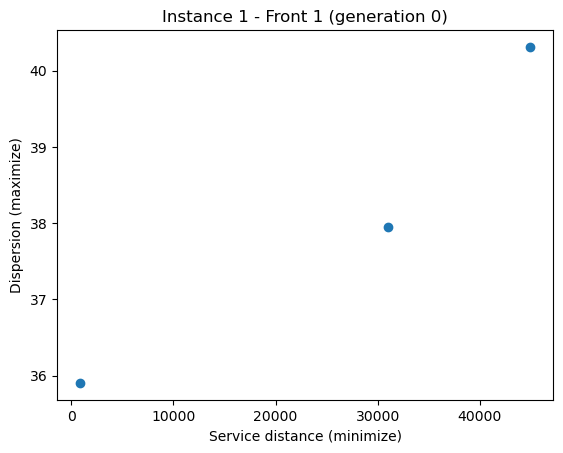

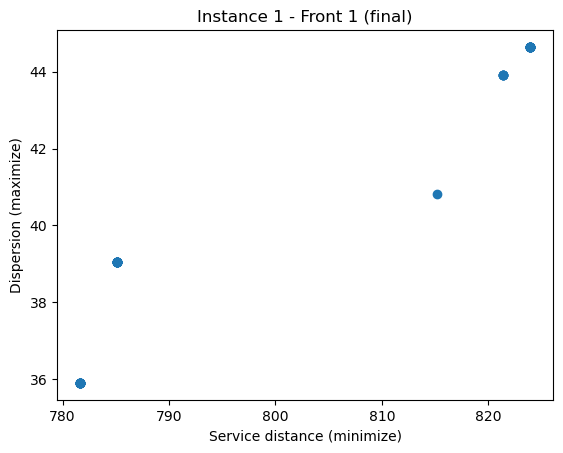

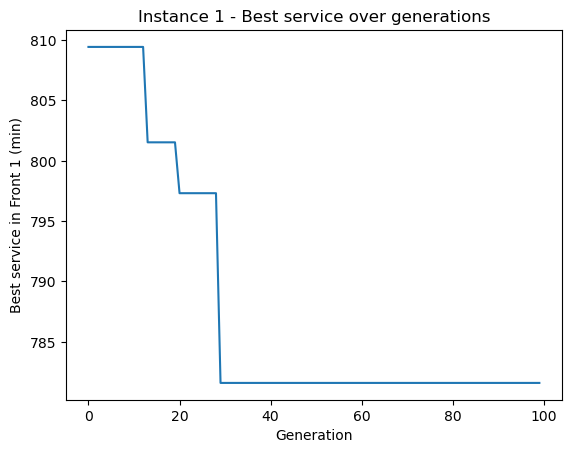

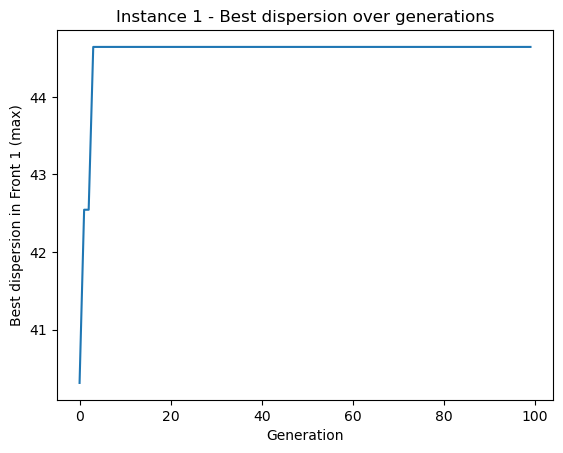

=== Summary ===
Instance ID: 1 | n: 50 | p: 5 | cap: 120 | best_known: 713
Final Front 1 size: 50
Min service in Front 1: 781.5947550695772
Max dispersion in Front 1: 44.64302857109943
Example solution (chrom) from Front 1: [37, 31, 32, 34, 27]


In [319]:
# ---------- Plotting ----------
def plot_front(front, title):
    s = [ind["service"] for ind in front]
    d = [ind["dispersion"] for ind in front]
    plt.figure()
    plt.scatter(s, d)
    plt.xlabel("Service distance (minimize)")
    plt.ylabel("Dispersion (maximize)")
    plt.title(title)
    plt.show()

# ---------- Run on one instance (change idx as needed) ----------
idx = 0  # instance index in `instances`
inst = build_distance_matrix(instances[idx])

final_pop, hist = nsga2_run(inst, pop_size=50, generations=100, mutation_rate=0.2, seed=1)

# Plots: front at start vs end
plot_front(hist["fronts"][0],  f"Instance {inst['id']} - Front 1 (generation 0)")
plot_front(hist["fronts"][-1], f"Instance {inst['id']} - Front 1 (final)")

# Progress plots
plt.figure()
plt.plot(hist["best_service"])
plt.xlabel("Generation")
plt.ylabel("Best service in Front 1 (min)")
plt.title(f"Instance {inst['id']} - Best service over generations")
plt.show()

plt.figure()
plt.plot(hist["best_dispersion"])
plt.xlabel("Generation")
plt.ylabel("Best dispersion in Front 1 (max)")
plt.title(f"Instance {inst['id']} - Best dispersion over generations")
plt.show()

# Small summary
front1_final = non_dominated_sort(final_pop)[0]
services = [ind["service"] for ind in front1_final]
dispersions = [ind["dispersion"] for ind in front1_final]
print("=== Summary ===")
print("Instance ID:", inst["id"], "| n:", inst["n"], "| p:", inst["p"], "| cap:", inst["cap"], "| best_known:", inst["best"])
print("Final Front 1 size:", len(front1_final))
print("Min service in Front 1:", min(services))
print("Max dispersion in Front 1:", max(dispersions))
print("Example solution (chrom) from Front 1:", front1_final[0]["chrom"])